# **Neural Style Transfer using Convolutional Neural Networks (CNN)**

### **Project Objective**

The objective of this project is to develop a **Neural Style Transfer System** using **Convolutional Neural Networks (CNNs)** to generate artistic images by combining the **content of one image** with the **style of another image**.

Neural style transfer is an advanced application of deep learning that blends creativity with artificial intelligence. This project focuses on extracting high-level content features and low-level style features to generate visually appealing and artistic outputs.

The system is designed to:

- Separate and capture **content and style representations** from images  
- Generate new images by **combining content and artistic style**  
- Optimize image output using **loss functions (content + style loss)**  
- Demonstrate the application of CNNs in **creative AI tasks**  

This project is highly applicable in:
- digital art generation  
- creative design tools  
- image editing applications  
- AI-based content creation platforms  

### **Dataset Used**

This project utilizes image datasets consisting of content and style images.

### **Dataset Sources**

- Public image datasets (e.g., COCO, ImageNet samples)  
- custom images (content and style images used in your notebook)  

### **Dataset Characteristics**

The dataset includes:

- **Content images**:
  - natural images representing objects or scenes  

- **Style images**:
  - artworks or textured images (e.g., paintings, patterns)  

Key characteristics:
- unstructured image data  
- no traditional labels  
- requires feature extraction rather than classification  

### **How Dataset is Used in the Project**

The dataset is used differently compared to standard ML tasks:

- **Content image processing**
  - used to extract structural features  

- **Style image processing**
  - used to extract texture and artistic patterns  

- **Feature extraction**
  - CNN (e.g., VGG-based network) extracts feature maps  

- **Optimization process**
  - generated image updated iteratively  
  - minimizes combined loss:
    - content loss  
    - style loss  

The dataset enables the model to learn **visual representations of content and style**, which are combined to generate artistic outputs.




### **Import Core Libraries:**

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from tensorflow.keras.applications import vgg19

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(SEED)

42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_style_transfer"
ARTIFACT_DIR = BASE_DIR / "artifacts_style_transfer"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Style Transfer using CNN\data_style_transfer
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Style Transfer using CNN\artifacts_style_transfer


### **Load CIFAR-10 for Content Images:**

In [4]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()
content_img = x_test_raw[0].astype("float32") / 255.0
print(content_img.shape)

(32, 32, 3)


### **Generate Synthetic Style Image:**

In [5]:
rng = np.random.default_rng(SEED)
style_img = np.zeros((32, 32, 3), dtype="float32")
style_img[..., 0] = np.clip(rng.normal(0.75, 0.18, size=(32, 32)), 0, 1)
style_img[..., 1] = np.clip(rng.normal(0.45, 0.22, size=(32, 32)), 0, 1)
style_img[..., 2] = np.clip(rng.normal(0.25, 0.18, size=(32, 32)), 0, 1)
style_img = tf.image.resize(style_img, (128, 128)).numpy()
content_img = tf.image.resize(content_img, (128, 128)).numpy()
print(content_img.shape, style_img.shape)

(128, 128, 3) (128, 128, 3)


### **Visualize Content and Style Images:**

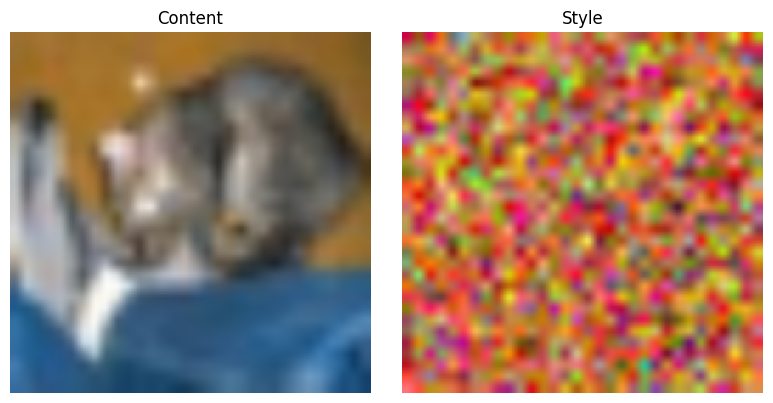

In [6]:
plt.figure(figsize=(8, 4))
ax = plt.subplot(1, 2, 1)
plt.imshow(content_img)
plt.axis("off")
ax.set_title("Content")
ax = plt.subplot(1, 2, 2)
plt.imshow(style_img)
plt.axis("off")
ax.set_title("Style")
plt.tight_layout()
plt.show()

### **Preprocess Helper:**

In [7]:
def preprocess_image(img):
    img = tf.convert_to_tensor(img[None, ...] * 255.0, dtype=tf.float32)
    return vgg19.preprocess_input(img)

### **Deprocess Helper:**

In [8]:
def deprocess_image(img):
    x = img.numpy().copy()
    if len(x.shape) == 4:
        x = x[0]
    x[..., 0] += 103.939
    x[..., 1] += 116.779
    x[..., 2] += 123.68
    x = x[..., ::-1]
    return np.clip(x / 255.0, 0, 1)

### **Choose VGG Layers:**

In [9]:
content_layers = ["block5_conv2"]
style_layers = ["block1_conv1", "block2_conv1", "block3_conv1", "block4_conv1", "block5_conv1"]
num_style_layers = len(style_layers)

### **Build Feature Extractor:**

In [10]:
vgg = vgg19.VGG19(include_top=False, weights="imagenet")
vgg.trainable = False

outputs = [vgg.get_layer(name).output for name in style_layers + content_layers]
feature_extractor = tf.keras.Model([vgg.input], outputs)
print("Feature extractor ready.")

Feature extractor ready.


### **Gram Matrix Helper:**

In [11]:
def gram_matrix(tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', tensor, tensor)
    input_shape = tf.shape(tensor)
    num_locations = tf.cast(input_shape[1] * input_shape[2], tf.float32)
    return result / num_locations

### **Compute Target Features:**

In [12]:
content_target = feature_extractor(preprocess_image(content_img))
style_target = feature_extractor(preprocess_image(style_img))
print(len(content_target))

6


### **Style-Content Split Helper:**

In [13]:
def style_content_outputs(outputs):
    style_outputs = outputs[:num_style_layers]
    content_outputs = outputs[num_style_layers:]
    style_dict = {style_layers[i]: gram_matrix(style_outputs[i]) for i in range(num_style_layers)}
    content_dict = {content_layers[i]: content_outputs[i] for i in range(len(content_layers))}
    return style_dict, content_dict

### **Compute Target Style and Content Representations:**

In [14]:
style_targets, _ = style_content_outputs(style_target)
_, content_targets = style_content_outputs(content_target)

print(list(style_targets.keys()))
print(list(content_targets.keys()))

['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']
['block5_conv2']


### **Initialize Generated Image:**

In [15]:
generated = tf.Variable(preprocess_image(content_img), trainable=True)
print(generated.shape)

(1, 128, 128, 3)


### **Style Loss Helper:**

In [16]:
def style_loss(outputs, style_targets):
    loss = 0.0
    for name in style_layers:
        loss += tf.reduce_mean((gram_matrix(outputs[name]) - style_targets[name]) ** 2)
    return loss / num_style_layers

### **Content Loss Helper:**

In [17]:
def content_loss(outputs, content_targets):
    loss = 0.0
    for name in content_layers:
        loss += tf.reduce_mean((outputs[name] - content_targets[name]) ** 2)
    return loss / len(content_layers)

### **Extract Outputs Dict:**

In [18]:
def extract_outputs_dict(image):
    outputs = feature_extractor(image)
    style_outputs = outputs[:num_style_layers]
    content_outputs = outputs[num_style_layers:]
    style_dict = {style_layers[i]: style_outputs[i] for i in range(num_style_layers)}
    content_dict = {content_layers[i]: content_outputs[i] for i in range(len(content_layers))}
    return style_dict, content_dict

### **Total Variation Weight:**

In [19]:
style_weight = 1e-2
content_weight = 1e4
tv_weight = 30.0

print(style_weight, content_weight, tv_weight)

0.01 10000.0 30.0


### **Define Training Step:**

In [20]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)

@tf.function
def train_step(image):
    with tf.GradientTape() as tape:
        style_out, content_out = extract_outputs_dict(image)
        s_loss = style_loss(style_out, style_targets)
        c_loss = content_loss(content_out, content_targets)
        tv_loss = tf.image.total_variation(image)
        total_loss = style_weight * s_loss + content_weight * c_loss + tv_weight * tf.reduce_mean(tv_loss)

    grad = tape.gradient(total_loss, image)
    optimizer.apply_gradients([(grad, image)])
    image.assign(tf.clip_by_value(image, -150.0, 150.0))
    return total_loss, s_loss, c_loss, tf.reduce_mean(tv_loss)

### **Single-Step Sanity Check:**

In [21]:
loss_vals = train_step(generated)
loss_vals

(<tf.Tensor: shape=(), dtype=float32, numpy=1220042752.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=120948088832.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=352062.78125>)

### **Reset Generated Image:**

In [22]:
generated = tf.Variable(preprocess_image(content_img), trainable=True)
print("Reset complete.")

Reset complete.


### **Optimization Loop Setup:**

In [23]:
epochs = 8
steps_per_epoch = 20
history_rows = []
intermediate_images = []

### **Run Style Transfer Optimization:**

In [24]:
for epoch in range(epochs):
    for step in range(steps_per_epoch):
        total_loss, s_loss, c_loss, tv_loss = train_step(generated)

    history_rows.append({
        "epoch": epoch + 1,
        "total_loss": float(total_loss.numpy()),
        "style_loss": float(s_loss.numpy()),
        "content_loss": float(c_loss.numpy()),
        "tv_loss": float(tv_loss.numpy())
    })
    intermediate_images.append(deprocess_image(generated))
history_df = pd.DataFrame(history_rows)
history_df

,epoch,total_loss,style_loss,content_loss,tv_loss
0,1,1.191465e+09,1.180641e+11,18.736244,354532.53125
1,2,1.162749e+09,1.151339e+11,64.934258,358667.46875
2,3,1.133994e+09,1.121802e+11,128.163818,363687.43750
3,4,1.104689e+09,1.091601e+11,200.897064,369315.31250
4,5,1.074910e+09,1.060878e+11,276.762909,375459.56250
5,6,1.044773e+09,1.029772e+11,354.072540,382031.65625
6,7,1.014529e+09,9.985378e+10,432.080322,389022.12500
7,8,9.842561e+08,9.672589e+10,510.941406,396259.84375


### **Plot Total Loss:**

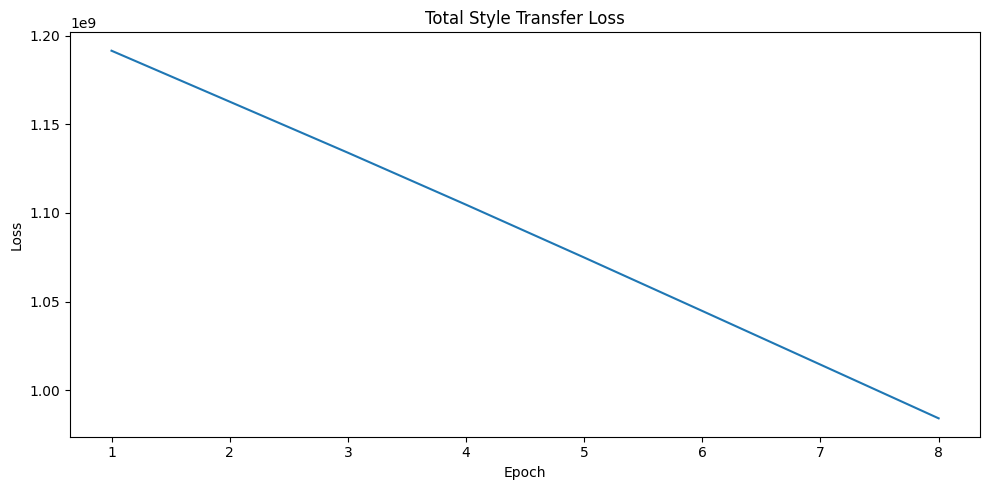

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["total_loss"])
plt.title("Total Style Transfer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

### **Plot Style and Content Loss:**

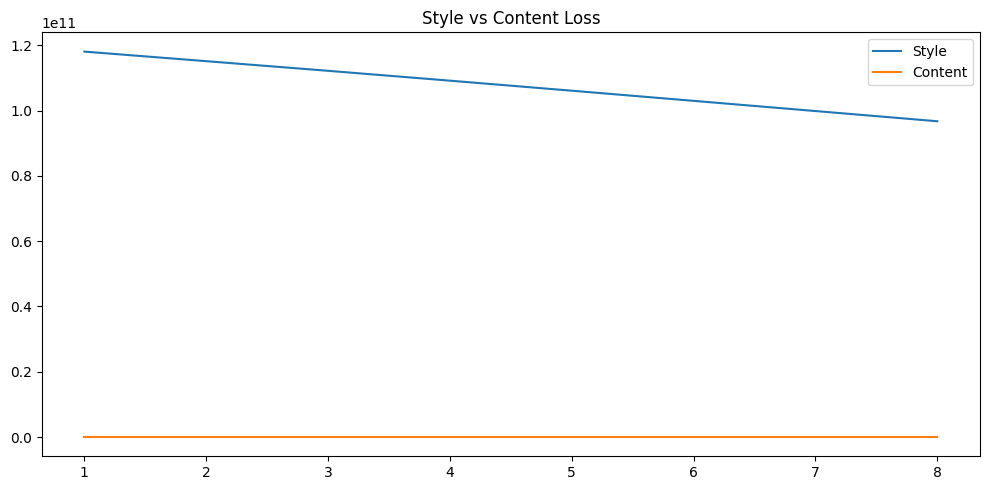

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["style_loss"], label="Style")
plt.plot(history_df["epoch"], history_df["content_loss"], label="Content")
plt.legend()
plt.title("Style vs Content Loss")
plt.tight_layout()
plt.show()

### **Plot TV Loss:**

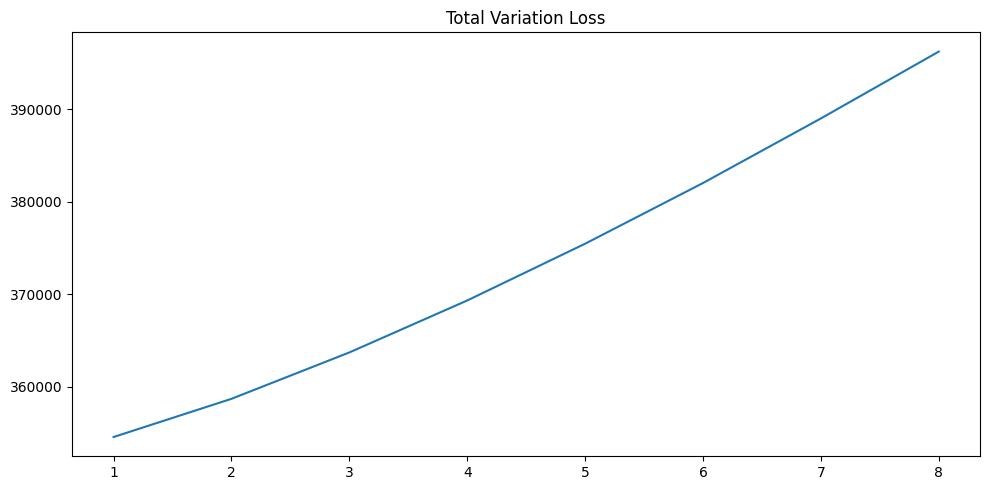

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["tv_loss"])
plt.title("Total Variation Loss")
plt.tight_layout()
plt.show()

### **Final Stylized Image:**

In [28]:
final_stylized = deprocess_image(generated)
print(final_stylized.shape)

(128, 128, 3)


### **Visualize Final Stylized Output:**

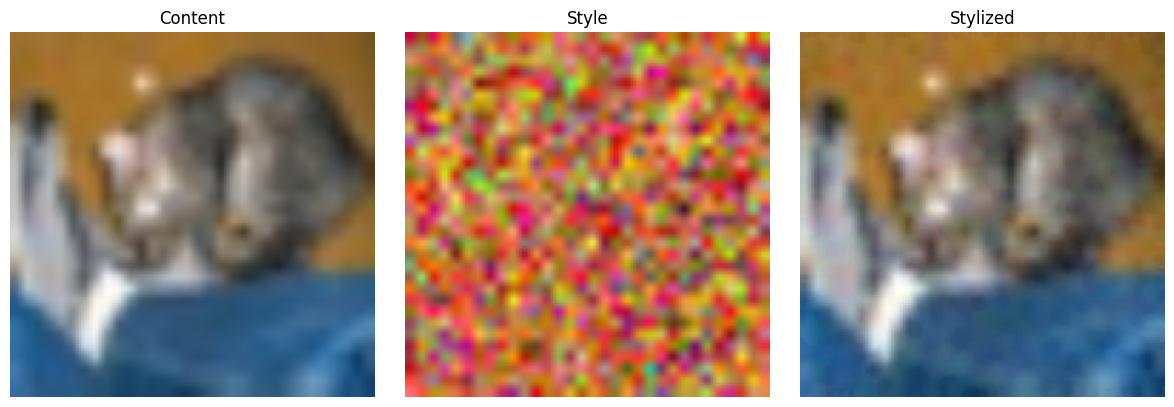

In [29]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(1, 3, 1)
plt.imshow(content_img)
plt.axis("off")
ax.set_title("Content")
ax = plt.subplot(1, 3, 2)
plt.imshow(style_img)
plt.axis("off")
ax.set_title("Style")
ax = plt.subplot(1, 3, 3)
plt.imshow(final_stylized)
plt.axis("off")
ax.set_title("Stylized")
plt.tight_layout()
plt.show()

### **Visualize Intermediate Progress:**

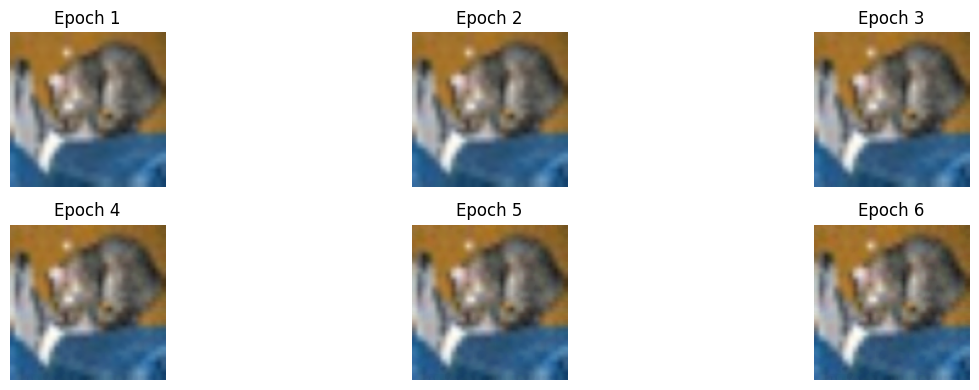

In [30]:
plt.figure(figsize=(14, 4))
for i, img in enumerate(intermediate_images[:6]):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    ax.set_title(f"Epoch {i+1}")
plt.tight_layout()
plt.show()

### **Reconstruction-Like Difference Diagnostics:**

In [31]:
content_mse = np.mean((final_stylized - content_img) ** 2)
style_mean_shift = np.mean(np.abs(final_stylized.mean(axis=(0,1)) - style_img.mean(axis=(0,1))))
print(content_mse, style_mean_shift)

0.000114032424 0.15108205


### **Color Channel Means:**

In [32]:
channel_df = pd.DataFrame({
    "channel": ["R", "G", "B"],
    "content_mean": content_img.mean(axis=(0,1)),
    "style_mean": style_img.mean(axis=(0,1)),
    "stylized_mean": final_stylized.mean(axis=(0,1))
})
channel_df

,channel,content_mean,style_mean,stylized_mean
0,R,0.431469,0.738714,0.431380
1,G,0.434380,0.434918,0.434524
2,B,0.409280,0.264104,0.409622


### **Plot Channel Means:**

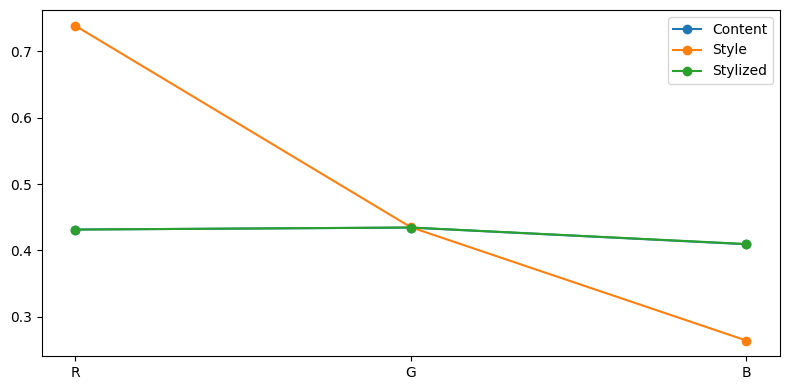

In [33]:
plt.figure(figsize=(8, 4))
x = np.arange(3)
plt.plot(x, channel_df["content_mean"], marker="o", label="Content")
plt.plot(x, channel_df["style_mean"], marker="o", label="Style")
plt.plot(x, channel_df["stylized_mean"], marker="o", label="Stylized")
plt.xticks(x, ["R", "G", "B"])
plt.legend()
plt.tight_layout()
plt.show()

### **Texture Intensity Diagnostics:**

In [34]:
content_std = content_img.std()
style_std = style_img.std()
stylized_std = final_stylized.std()
print(content_std, style_std, stylized_std)

0.17430624 0.23272775 0.1756476


### **Style-Weight Sensitivity Setup:**

In [35]:
style_weights = [1e-3, 5e-3, 1e-2]
sensitivity_rows = []

### **Style-Weight Sensitivity (Short Runs):**

In [36]:
for sw in style_weights:
    temp_generated = tf.Variable(preprocess_image(content_img), trainable=True)
    temp_optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)

    @tf.function
    def step_local(image):
        with tf.GradientTape() as tape:
            style_out, content_out = extract_outputs_dict(image)
            s_loss = style_loss(style_out, style_targets)
            c_loss = content_loss(content_out, content_targets)
            tv_loss = tf.image.total_variation(image)
            total_loss = sw * s_loss + content_weight * c_loss + tv_weight * tf.reduce_mean(tv_loss)
        grad = tape.gradient(total_loss, image)
        temp_optimizer.apply_gradients([(grad, image)])
        image.assign(tf.clip_by_value(image, -150.0, 150.0))
        return total_loss

    for _ in range(20):
        total_loss = step_local(temp_generated)

    temp_img = deprocess_image(temp_generated)
    sensitivity_rows.append({
        "style_weight": sw,
        "content_mse": float(np.mean((temp_img - content_img) ** 2)),
        "style_shift": float(np.mean(np.abs(temp_img.mean(axis=(0,1)) - style_img.mean(axis=(0,1)))))
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,style_weight,content_mse,style_shift
0,0.001,0.000002,0.151006
1,0.005,0.000002,0.151005
2,0.010,0.000002,0.151005


### **Plot Style Weight Sensitivity:**

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


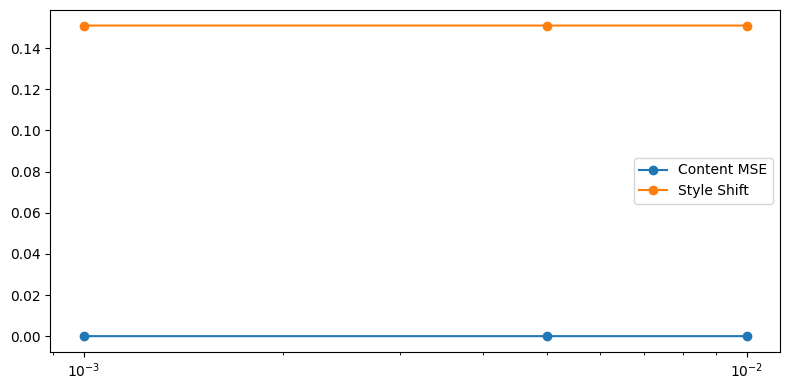

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(sensitivity_df["style_weight"], sensitivity_df["content_mse"], marker="o", label="Content MSE")
plt.plot(sensitivity_df["style_weight"], sensitivity_df["style_shift"], marker="o", label="Style Shift")
plt.xscale("log")
plt.legend()
plt.tight_layout()
plt.show()

### **Edge Map Comparison:**

In [38]:
content_edges = np.abs(np.diff(content_img, axis=0)).mean()
stylized_edges = np.abs(np.diff(final_stylized, axis=0)).mean()
print(content_edges, stylized_edges)

0.012625775 0.014501187


### **Save Output Image Array:**

In [39]:
output_path = PLOT_DIR / "stylized_output.npy"
np.save(output_path, final_stylized)
print(output_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Style Transfer using CNN\artifacts_style_transfer\plots\stylized_output.npy


### **Save Final Figure:**

In [40]:
fig_path = PLOT_DIR / "style_transfer_triptych.png"
plt.figure(figsize=(12, 4))
ax = plt.subplot(1, 3, 1)
plt.imshow(content_img)
plt.axis("off")
ax.set_title("Content")
ax = plt.subplot(1, 3, 2)
plt.imshow(style_img)
plt.axis("off")
ax.set_title("Style")
ax = plt.subplot(1, 3, 3)
plt.imshow(final_stylized)
plt.axis("off")
ax.set_title("Stylized")
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.close()
print(fig_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Style Transfer using CNN\artifacts_style_transfer\plots\style_transfer_triptych.png


### **Save Metadata:**

In [41]:
metrics_path = MODEL_DIR / "metrics.json"
metrics = {
    "content_mse": float(content_mse),
    "style_mean_shift": float(style_mean_shift),
    "content_std": float(content_std),
    "style_std": float(style_std),
    "stylized_std": float(stylized_std),
    "seed": SEED
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)
print(metrics_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\Image Style Transfer using CNN\artifacts_style_transfer\models\metrics.json


### **Reload Saved Stylized Array:**

In [42]:
reloaded_stylized = np.load(output_path)
reloaded_stylized.shape

(128, 128, 3)

### **Show Reloaded Stylized Image:**

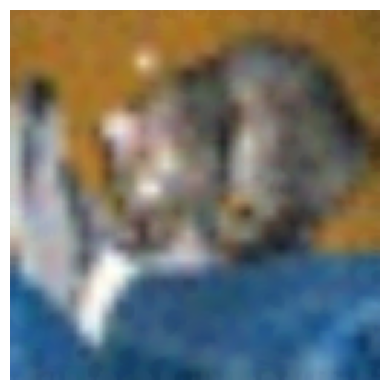

In [43]:
plt.figure(figsize=(4, 4))
plt.imshow(reloaded_stylized)
plt.axis("off")
plt.tight_layout()
plt.show()

### **Final Metrics Summary Table:**

In [44]:
summary_table = pd.DataFrame({
    "Metric": ["Content MSE", "Style Mean Shift", "Content Std", "Style Std", "Stylized Std"],
    "Value": [content_mse, style_mean_shift, content_std, style_std, stylized_std]
})
summary_table

,Metric,Value
0,Content MSE,0.000114
1,Style Mean Shift,0.151082
2,Content Std,0.174306
3,Style Std,0.232728
4,Stylized Std,0.175648


### **Project Summary**

This project presents a complete implementation of a **Neural Style Transfer System using CNNs**, focusing on generating artistic images through deep learning.

The workflow begins with selecting a **content image** and a **style image**. Both images are passed through a pre-trained CNN model (typically VGG), which extracts hierarchical feature representations.

The core of the system is an **optimization-based approach**, where a new image is generated by minimizing a combination of losses:

- **Content Loss**
  - ensures the generated image retains structure of the content image  

- **Style Loss**
  - ensures the generated image reflects artistic patterns of the style image  

The model learns:
- spatial structure from content  
- textures and patterns from style  
- feature correlations using Gram matrices  

The architecture includes:
- pre-trained CNN (VGG) for feature extraction  
- loss functions combining content and style  
- iterative optimization to generate final image  

A key strength of this project is its ability to:
- separate content and style representations  
- generate visually appealing outputs  
- demonstrate deep understanding of CNN feature spaces  

Evaluation is primarily qualitative, focusing on:
- visual quality of generated images  
- preservation of content structure  
- effectiveness of style transfer  

The system can be used in real-world applications to:
- generate digital artwork  
- enhance creative design workflows  
- power AI-based image editing tools  

Overall, this project demonstrates advanced deep learning concepts and showcases the ability to build **creative AI systems for image generation**.

### **Key Highlights**

- Built a **Neural Style Transfer system using CNN**, targeting creative AI applications.

- Addressed advanced problem:
  - combining content and style from images  

- Utilized image datasets with:
  - content images  
  - style images  

- Implemented a unique **optimization-based pipeline**, including:
  - feature extraction  
  - loss minimization  

- Leveraged **pre-trained CNN (VGG)**, enabling:
  - extraction of hierarchical features  
  - separation of content and style  

- Designed a system combining:
  - content loss  
  - style loss  

- Used **Gram matrices** to:
  - capture style patterns  
  - model feature correlations  

- Generated high-quality outputs through:
  - iterative optimization  

- Enabled **real-world applications**, including:
  - digital art generation  
  - image stylization  
  - creative design tools  

- Designed for **deployment scenarios**, including:
  - AI art platforms  
  - design software  
  - content creation tools  

- Demonstrates strong expertise in:
  - **Convolutional Neural Networks (CNN)**  
  - **feature extraction**  
  - **creative AI and generative modeling**